# Predicting the parameter bias from a wrong n(z)

`FisherFlex.forecast` says how *precisely* a survey measures cosmology.  This notebook
uses `FisherFlex.forecast_bias` to ask the other question: if the true source n(z) is not
the one we assumed, how far off is the answer?

It uses the DESC nz-challenge task-set 1 (Cardinal, 1yr, WFD) files in this directory,
where the *truth* is known -- so we can measure the bias rather than guess at it.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from fisherA2Z.fisher_flex import FisherFlex
from fisherA2Z import nz_shift_stretch as nzss
import tables_io
import qp
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

### grab the central n(z) and the zgrid

In [2]:
qp_nz = qp.read('./nz_challenge_taskset_1_cardinal_nz_samples_1yr_wfd.hdf5')

z_grid = np.linspace(0.01, 3.0, 150)

nz_realization = np.swapaxes(qp_nz.pdf(z_grid).reshape(5, 10, 150), 0, 1)
nz_central = np.mean(qp_nz.pdf(z_grid).reshape(5, 10, 150), axis=1)

### calculate the effective number density

In [3]:
N_OBJECTS = dict(
    taskset_1 = dict(
        flagship_1yr = 3625282,
        flagship_4yr = 3617704,
        cardinal_1yr = 3505864,
        cardinal_4yr = 3500333,
    ),
)

# For the WFD files we selection 1M objects from the catalogs
N_SAMPLED_OBJ = 1000000

# This is the total area of the sims (32 HEALPix nside=32 pixels)
SIM_SKY_AREA_MIN2 = 107.4295 * 3600

TOTAL_EFFECTIVE_DENSITY = dict(
    taskset_1 = {key: n_obj / SIM_SKY_AREA_MIN2
                 for key, n_obj in N_OBJECTS['taskset_1'].items()},
)


def tomo_bins_effective_density(n_objects, taskset, sim, scenario):
    """Effective number density for the tomographic bins, in gal / arcmin^2."""
    conversion = TOTAL_EFFECTIVE_DENSITY[taskset][f"{sim}_{scenario}"]
    return n_objects * conversion / N_SAMPLED_OBJ


bhat_table = tables_io.read('./nz_challenge_taskset_1_cardinal_1yr_bhat_wfd.hdf5')
counts = np.bincount(bhat_table['bhat_for_wide_data'], minlength=5)[0:5]
neff = tomo_bins_effective_density(counts, 'taskset_1', 'cardinal', '1yr')

print(f'number counts in bins = {counts}')
print(f'effective number density in bins = {neff}')

number counts in bins = [196661 196375 189284 214686 202994]
effective number density in bins = [1.7827369  1.7801443  1.71586421 1.94613397 1.8401457 ]


### the truth

`..._nz_true_wfd.hdf5` holds the true n(z) of the same five bins, as a histogram.
`qp` puts it straight onto our grid.

In [4]:
nz_true = qp.read('./nz_challenge_taskset_1_cardinal_1yr_nz_true_wfd.hdf5').pdf(z_grid)

mean_true = np.trapz(nz_true * z_grid, z_grid, axis=1) / np.trapz(nz_true, z_grid, axis=1)
mean_cen = np.trapz(nz_central * z_grid, z_grid, axis=1) / np.trapz(nz_central, z_grid, axis=1)

print(f"{'bin':<5}{'<z> true':>10}{'<z> central':>13}{'difference':>12}")
for i in range(5):
    print(f"{i+1:<5}{mean_true[i]:>10.4f}{mean_cen[i]:>13.4f}{mean_true[i]-mean_cen[i]:>+12.4f}")

bin    <z> true  <z> central  difference
1        0.2145       0.2181     -0.0037
2        0.3934       0.3949     -0.0015
3        0.5372       0.5343     +0.0028
4        0.6875       0.6861     +0.0014
5        0.9132       0.9046     +0.0086


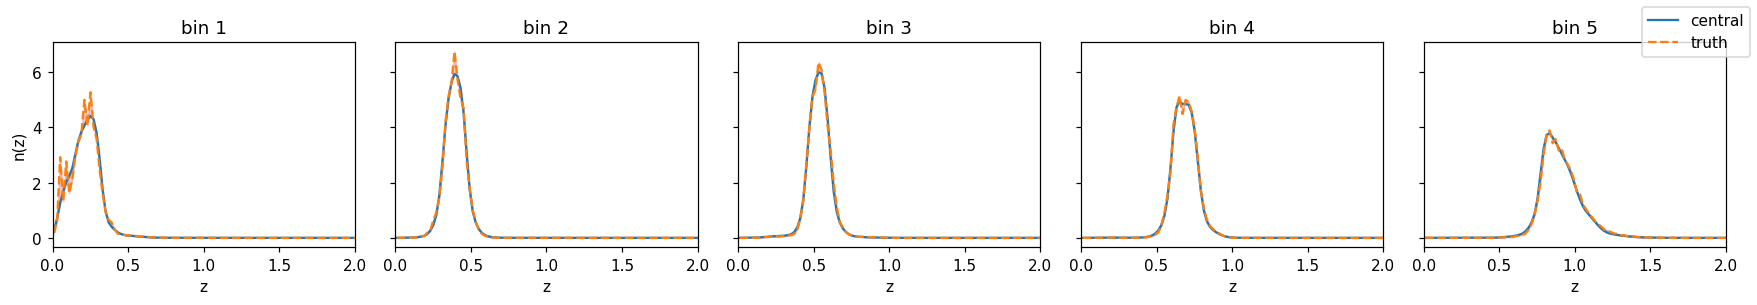

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(16, 2.8), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(z_grid, nz_central[i], color='C0', label='central' if i == 0 else None)
    ax.plot(z_grid, nz_true[i], color='C1', ls='--', label='truth' if i == 0 else None)
    ax.fill_between(z_grid, nz_central[i], nz_true[i], color='C3', alpha=0.25)
    ax.set_title(f'bin {i+1}')
    ax.set_xlabel('z')
    ax.set_xlim(0, 2)
axes[0].set_ylabel('n(z)')
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

### the forecast

Same 3x2pt setup as `forecast_example.ipynb`.  The n(z) we hand it is the **central**
one -- the truth is not used here, only in the bias step below.

In [7]:
flex = FisherFlex(
    # -- the n(z) and its uncertainty ---------------------------------
    nz_source=nz_central,
    nz_realizations=None,
    z_grid=z_grid,
    # -- the survey ---------------------------------------------------
    neff_source=neff,                   # arcmin^-2, per tomographic bin
    fsky=0.5,
    sigma_e=0.26,                       # per-component ellipticity dispersion
    # -- the analysis -------------------------------------------------
    mode="cosmic_shear",
    nz_model="no_uncertainty",
)

flex.compute(parallel=True, save="nzdc_y1_3x2pt.npz")

forecast_params = dict(ell_max_cs=1800, ell_min_cs=300)
res = flex.forecast(**forecast_params)

s8, s8_err = res.s8()
print(f"LSST Y1 3x2pt S_8 = {s8:.4f} +/- {s8_err:.4f}")
print(f"FoM(w0,wa) = {res.fom('w_0', 'w_a'):.2f}")

Computing the fiducial data vector and covariance ...
Computing derivatives for 21 parameters (parallel) ...
Done.
Saved to nzdc_y1_3x2pt.npz
LSST Y1 3x2pt S_8 = 0.8523 +/- 0.0139
FoM(w0,wa) = 4.11


### predict the bias

`forecast_bias` forward-models the data vector twice -- once with the central n(z), once
with the truth -- and pushes the residual through Eq. (13) of the FisherA2Z paper,

$$f_\alpha = \mathbb{I}^{-1}\cdot\left(\frac{dC_\ell}{d\alpha}\cdot V\cdot(C_\ell^{\rm biased}-C_\ell)\right)$$

Everything `forecast()` accepts goes in `forecast_params`, so the bias is quoted against
exactly the forecast above -- same scale cuts, same priors.

In [8]:
bias = flex.forecast_bias(nz_truth=nz_true, forecast_params=forecast_params)

print(bias.summary(["omega_m", "sigma_8", "w_0", "w_a"]))

s8_fid, s8_shifted, ds8, ds8_sigma = bias.s8()
print(f"\nS_8: {s8_fid:.4f} -> {s8_shifted:.4f}  ({ds8:+.4f}, {ds8_sigma:+.2f} sigma)")

parameter         fiducial        bias  bias/sigma     shifted
omega_m             0.3156  -0.0097729      -0.388     0.30583
sigma_8              0.831   0.0093038       0.270      0.8403
w_0                     -1    -0.10933      -0.299     -1.1093
w_a                      0    -0.04941      -0.044    -0.04941

S_8: 0.8523 -> 0.8484  (-0.0039, -0.28 sigma)


### the bias in a 2d plane

`bias/sigma` treats each parameter on its own.  `bias_2d` marginalizes over everything
else and measures the shift against the 2x2 covariance -- the contour you actually plot.
A shift can be small in both marginal error bars and still sit outside the ellipse, if it
runs *across* the degeneracy instead of along it, so the two questions have different
answers.

In [10]:
for pair in [("omega_m", "sigma_8"), ("w_0", "w_a")]:
    print(bias.bias_2d(*pair))
    print()

bias in the (omega_m, sigma_8) plane
  omega_m           0.3156 ->     0.30583   (-0.39 sigma_1D)
  sigma_8            0.831 ->      0.8403   (+0.27 sigma_1D)
  joint: chi2 = 0.199, sqrt(chi2) = 0.45, enclosing 9.5% of the posterior
  direction: +136.4 deg;  inside 1 sigma: True;  inside 2 sigma: True

bias in the (w_0, w_a) plane
  w_0                   -1 ->     -1.1093   (-0.30 sigma_1D)
  w_a                    0 ->    -0.04941   (-0.04 sigma_1D)
  joint: chi2 = 0.325, sqrt(chi2) = 0.57, enclosing 15.0% of the posterior
  direction: -155.7 deg;  inside 1 sigma: True;  inside 2 sigma: True



In [14]:
# bias in the 2d plane

# bias in om-sigma8 plane 
print(bias.bias_2d("omega_m", "sigma_8").confidence)

# bias in wowa plane 
print(bias.bias_2d("w_0", "w_a").confidence)

0.09492732383595515
0.15003077961738964


### plot it

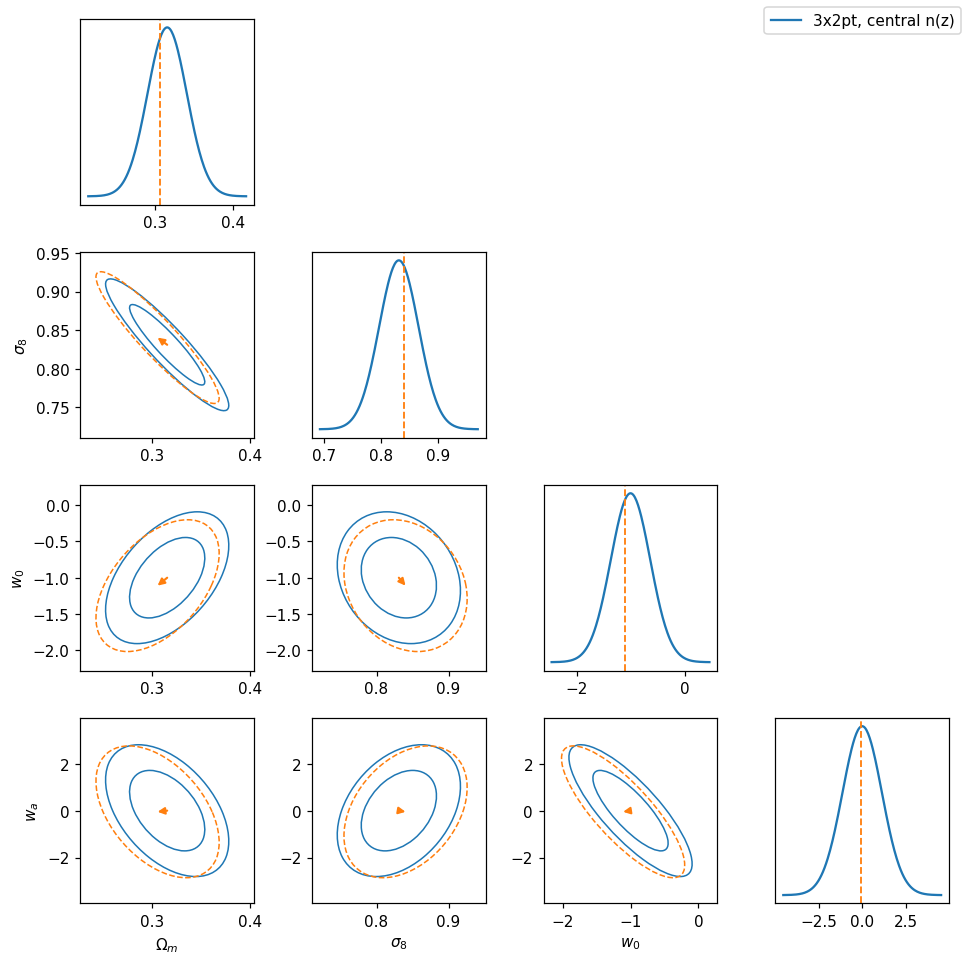

In [11]:
params = ["omega_m", "sigma_8", "w_0", "w_a"]

fig = res.corner(params, color="C0", label="3x2pt, central n(z)")
bias.corner_arrows(params, fig=fig, shifted_contour=True, color="C1")
fig.legend(loc="upper right", fontsize=10)
plt.show()

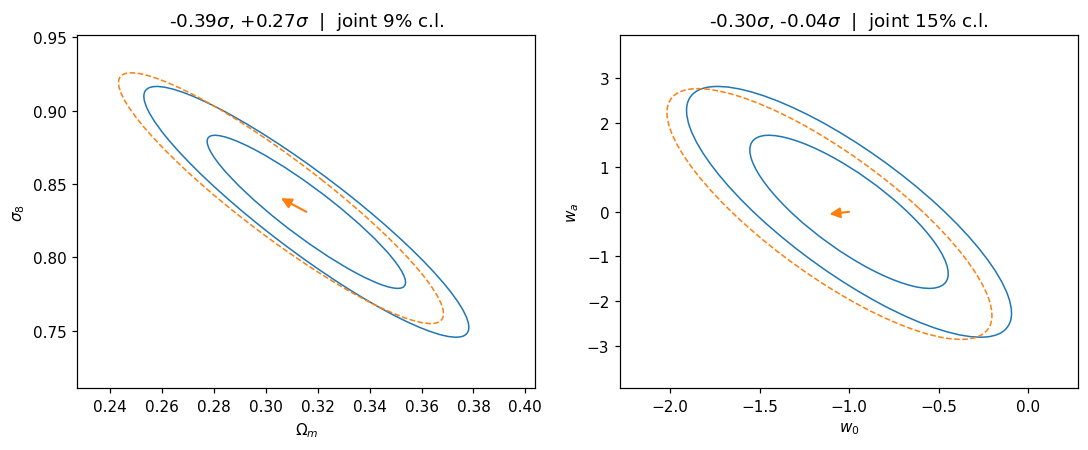

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (p1, p2) in zip(axes, [("omega_m", "sigma_8"), ("w_0", "w_a")]):
    res.contour(p1, p2, ax=ax, color="C0")
    bias.arrow(p1, p2, ax=ax, shifted_contour=True, color="C1")
    b2 = bias.bias_2d(p1, p2)
    ax.set_title(f"{bias.n_sigma(p1):+.2f}$\sigma$, {bias.n_sigma(p2):+.2f}$\sigma$"
                 f"  |  joint {b2.confidence:.0%} c.l.")
plt.tight_layout()
plt.show()